I suggest there is some minima by DBCV score along the epsilon being changed.
I d like to make many clusterings to find the corresponding minima.
We would need a precomputed dataset of 50PCs for some dataset and k neighbors data.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data_dir = 'epsilon_estimation/'

In [3]:
pc_data = pd.read_parquet(data_dir + 'pc_data.parquet')

In [4]:
distances = pd.read_parquet(data_dir + 'distances.parquet')

In [5]:
pc_data

,pc_0,pc_1,pc_2,pc_3,pc_4,pc_5,pc_6,pc_7,pc_8,pc_9,...,pc_40,pc_41,pc_42,pc_43,pc_44,pc_45,pc_46,pc_47,pc_48,pc_49
0,30.701809,-41.659786,-16.601965,7.468825,9.436491,-7.307352,7.843000,22.312531,-21.620718,-5.312843,...,-1.683577,-1.471420,2.296379,4.379124,-1.993255,-2.891953,7.504628,-2.759679,-1.679451,-6.457240
1,10.104598,29.549593,34.644024,-59.548328,63.423416,-47.248497,13.010448,-13.545800,11.393041,4.046199,...,1.712455,3.897314,-2.284050,-0.329637,-2.896786,0.365778,0.465226,1.826185,1.184378,0.194873
2,-65.594330,-36.133255,-10.158239,3.630771,2.696927,-2.812003,3.350186,7.233897,-16.107044,-3.803679,...,-5.846468,1.808612,2.026351,0.410481,-0.351183,-1.119095,1.672745,1.942150,4.401435,4.452356
3,-62.441242,37.608650,-4.173775,13.667619,10.676105,28.772995,1.481384,0.288311,-17.317215,27.392611,...,-3.117031,-3.021190,-2.864602,-5.609328,-8.642627,-4.256498,3.149652,-9.142597,-7.409142,-0.948513
4,44.773575,6.440123,-58.938686,-26.157265,-33.939438,-28.567318,25.008003,12.866024,-16.598557,2.214680,...,5.741800,4.562676,3.733692,0.438605,-6.670517,-3.341567,3.183042,-4.331459,-4.512940,2.137379
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
312046,-58.671978,29.679291,-28.029867,-15.770443,-37.462017,0.603335,20.332890,-1.535550,29.672964,5.390655,...,-1.804027,-1.065430,-3.615750,8.349241,-0.635928,-6.666240,-2.910106,-10.947863,-2.980044,-4.263554
312047,26.125315,-52.393654,-26.294415,-2.018836,-2.225484,9.503499,-8.115047,-20.210377,22.464464,10.128750,...,-2.536029,-5.678782,0.853258,4.211340,0.474483,-1.558680,-2.693427,-2.854656,-3.267687,-4.499404
312048,0.617590,15.094310,-22.938807,-67.818092,-36.024960,-19.768188,12.441541,-21.815165,-10.305173,1.387467,...,-2.612008,-1.505417,-0.349197,1.378045,-2.077204,-1.616784,4.827489,-2.899573,-0.354224,-2.330459
312049,-58.549282,-35.357315,-22.156033,-15.006502,10.473058,2.047151,7.637917,-0.117254,-5.879786,-4.024354,...,-4.446055,0.145263,-1.175858,5.510253,-0.758200,-8.283106,-1.858543,-8.385212,-3.077598,4.721227


In [6]:
distances

,n_0,n_1,n_2,n_3
0,0.000002,13.289989,13.289989,15.059175
1,0.000003,12.909882,13.411575,13.412416
2,0.000000,7.735253,18.459782,20.293535
3,0.000002,21.773575,24.578175,26.694517
4,0.000000,11.404862,11.690366,11.942976
...,...,...,...,...
312046,0.000003,18.806049,22.622765,24.348257
312047,0.000000,16.921425,18.831787,21.135885
312048,0.000002,14.965383,15.669857,16.459822
312049,0.000002,13.924322,14.237141,15.395370


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import NearestNeighbors
from hdbscan.validity import validity_index  # убедись, что пакет установлен

In [33]:
from sklearn.cluster import DBSCAN
from hdbscan.validity import validity_index
import numpy as np

def get_core_mask(distances, eps):
    """Маска точек, у которых расстояние до ближайшего соседа ≤ eps"""
    return distances <= eps

def relabel_singleton_clusters(labels):
    """Переопределяет кластеры, встречающиеся только один раз, в -1"""
    labels = labels.copy()
    unique, counts = np.unique(labels[labels != -1], return_counts=True)
    singletons = unique[counts == 1]
    for val in singletons:
        labels[labels == val] = -1
    return labels

def run_dbscan_on_core_and_dbcv_wo_noise(pc_data, distances, eps, min_samples=5):
    # 1. Core mask
    core_mask = get_core_mask(distances, eps)
    core_data = pc_data[core_mask]

    # 2. Инициализируем метки как -1
    labels = np.full(len(pc_data), -1, dtype=int)

    # 3. Кластеризуем только ядро
    db = DBSCAN(eps=eps, min_samples=min_samples)
    core_labels = db.fit_predict(core_data)
    

    # 4. Назначаем метки в общий массив
    labels[core_mask] = core_labels

    # 5. Удаляем одиночные кластеры
    labels = relabel_singleton_clusters(labels)
    
    score = len(labels[labels == -1])
#     # 6. Выкидываем -1 перед DBCV
#     mask = labels != -1
#     if len(set(labels[mask])) <= 1:
#         return np.nan, labels  # некорректно для DBCV

#     score = validity_index(pc_data[mask].astype(np.float64), labels[mask].astype(np.intp))

    return score, labels

def evaluate_eps_range(pc_data, distances, eps_range, min_samples=5):
    results = []
    for eps in eps_range:
        score, labels = run_dbscan_on_core_and_dbcv_wo_noise(pc_data, distances, eps, min_samples)
        print(f"eps={eps:.3f}, noise points={score}")
        results.append((eps, score))
    return results


In [34]:
distances

,n_0,n_1,n_2,n_3
0,0.000002,13.289989,13.289989,15.059175
1,0.000003,12.909882,13.411575,13.412416
2,0.000000,7.735253,18.459782,20.293535
3,0.000002,21.773575,24.578175,26.694517
4,0.000000,11.404862,11.690366,11.942976
...,...,...,...,...
312046,0.000003,18.806049,22.622765,24.348257
312047,0.000000,16.921425,18.831787,21.135885
312048,0.000002,14.965383,15.669857,16.459822
312049,0.000002,13.924322,14.237141,15.395370


In [48]:
from sklearn.neighbors import NearestNeighbors

nearest_dist = distances.n_1  # расстояние до ближайшего соседа

eps_range = np.linspace(1, 31, 30)

In [49]:
results = evaluate_eps_range(pc_data.astype(np.float64).values, nearest_dist, eps_range)


eps=1.000, noise points=311737
eps=2.034, noise points=311731
eps=3.069, noise points=311597
eps=4.103, noise points=311333
eps=5.138, noise points=311055
eps=6.172, noise points=310559
eps=7.207, noise points=309572
eps=8.241, noise points=307719
eps=9.276, noise points=304388
eps=10.310, noise points=299170
eps=11.345, noise points=292273
eps=12.379, noise points=282593
eps=13.414, noise points=271451
eps=14.448, noise points=257540
eps=15.483, noise points=241979
eps=16.517, noise points=225243
eps=17.552, noise points=207023
eps=18.586, noise points=188244
eps=19.621, noise points=168779
eps=20.655, noise points=149413
eps=21.690, noise points=130012
eps=22.724, noise points=111258
eps=23.759, noise points=94117
eps=24.793, noise points=78554
eps=25.828, noise points=64633
eps=26.862, noise points=52151
eps=27.897, noise points=41353
eps=28.931, noise points=32459
eps=29.966, noise points=25147
eps=31.000, noise points=19298


In [50]:
results = np.array(results)

In [51]:
results[:, 0]

array([ 1.        ,  2.03448276,  3.06896552,  4.10344828,  5.13793103,
        6.17241379,  7.20689655,  8.24137931,  9.27586207, 10.31034483,
       11.34482759, 12.37931034, 13.4137931 , 14.44827586, 15.48275862,
       16.51724138, 17.55172414, 18.5862069 , 19.62068966, 20.65517241,
       21.68965517, 22.72413793, 23.75862069, 24.79310345, 25.82758621,
       26.86206897, 27.89655172, 28.93103448, 29.96551724, 31.        ])

<Axes: >

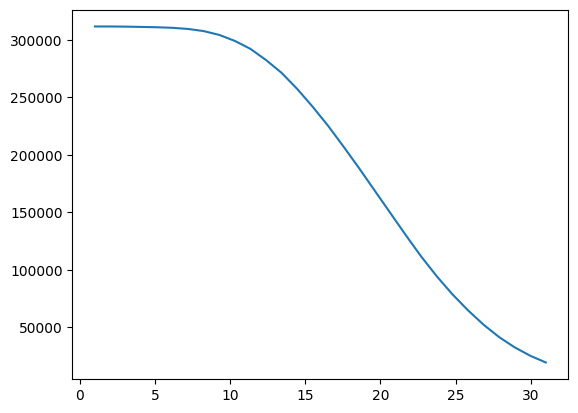

In [52]:
sns.lineplot(x=results[:, 0], y=results[:, 1])